This routine generates **Figure 5** and its supplementary figures. If you have any questions please contact [a.sarfraz@uu.nl](mailto:a.sarfraz@uu.nl).

### Imports

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import cm
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyBboxPatch
from matplotlib.colors import LinearSegmentedColormap

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.base import clone
from sklearn.model_selection import (GridSearchCV, GroupKFold,
                                     cross_val_predict)
from sklearn.metrics import r2_score, mean_absolute_error

import shap
from matplotlib import colormaps
from itertools import combinations
from IPython.display import display

warnings.filterwarnings("ignore")


### Setting directories

In [2]:
from __future__ import annotations

import sys
import yaml

# Resolve the repo root from this notebook's location.
_NB_DIR   = Path.cwd()
REPO_ROOT = _NB_DIR.parent if _NB_DIR.name == "notebooks" else _NB_DIR

# Expose the shared package.
sys.path.insert(0, str(REPO_ROOT / "src"))

# Load the path config.
_cfg = yaml.safe_load((REPO_ROOT / "config" / "paths.yaml").read_text())

def _resolve(p):
    p = Path(p)
    return p if p.is_absolute() else (REPO_ROOT / p).resolve()

PATHS = {
    "data":    {k: _resolve(v) for k, v in _cfg["data"].items()},
    "outputs": {k: _resolve(v) for k, v in _cfg["outputs"].items()},
}

from potable_reuse.style import apply_style, AXIS_LABEL_SIZE, SAVE_DPI
apply_style()

MERGED_DIR = PATHS["data"]["merged_parquets_dir"]

# outputs/figure5/
#   figure5_main_shap_MRC_vertical.png   the figure
#   SI/       tree and SHAP panels for each reuse cost tier
#   tables/   per-region SHAP tables, model skill, leaf rosters
FIG_DIR = PATHS["outputs"].get("figure5", REPO_ROOT / "outputs" / "figure5")
SI_DIR  = FIG_DIR / "SI"
TAB_DIR = FIG_DIR / "tables"
for d in (FIG_DIR, SI_DIR, TAB_DIR):
    d.mkdir(parents=True, exist_ok=True)

TUNE         = True
RANDOM_STATE = 42

print('Repo root  :', REPO_ROOT)
print('Merged dir :', MERGED_DIR)
print('Tune GBT   :', TUNE)


Repo root  : C:\Users\Sarfr001\Documents\Global_Potential_Potable_Reuse
Merged dir : C:\Users\Sarfr001\Documents\Global_Potential_Potable_Reuse\data\merged_parquets
Tune GBT   : True


### Constants

Lagged design: features at 2050 under PR0, target at 2100 under PR100. The model uses three predictors; the four-predictor set only fixes the rows, so every model sees the same data.

In [3]:

HEADLINE = dict(
    feat_year   = 2050,
    target_year = 2100,
    pr_level    = 'PR100',
)
TARGET    = 'pct_reduction'

# Exemplar regions
EXEMPLARS = ['Middle East', 'Pakistan', 'USA', 'Japan']

# renaming
FEATURE_PRETTY = {
    'mun_w_pr0':    'Municipal withdrawal',
    'pop':          'Population',
    'gdp_pcap_mer': 'GDP per capita',
    'gw_w_pr0':     'Groundwater withdrawal',
}


REGIONAL_FEATURES_BASE = ['gw_w_pr0', 'gdp_pcap_mer', 'pop']
REGIONAL_FEATURES_FULL = ['gw_w_pr0', 'gdp_pcap_mer', 'pop', 'mun_w_pr0']

# Reuse-cost tiers.
RC_MAP   = {'LRC': 0, 'MRC': 1, 'HRC': 2}
RC_ORDER = ['LRC', 'MRC', 'HRC']
RC_WORD  = {'LRC': 'low', 'MRC': 'medium', 'HRC': 'high'}

# Tier colors used in the cross-tier SI panel.
COL_LRC, COL_MRC, COL_HRC = '#1f4e99', '#e8923c', '#b03020'
RC_COLOR = {'LRC': COL_LRC, 'MRC': COL_MRC, 'HRC': COL_HRC}

EXEMPLAR_COLORS = {
    'USA':         '#1f77b4',
    'Middle East': '#a8324a',
    'Pakistan':    '#9467bd',
    'Japan':       '#1f77b4',
}

REGION_ABBREV = {
    'Middle East': 'M. East',
    'Pakistan':    'Pak',
    'USA':         'USA',
    'Japan':       'Japan',
}


def feature_columns(feat_year, base=None):
    """Predictor column names with the feature-year suffix attached."""
    base = REGIONAL_FEATURES_BASE if base is None else base
    return [f'{c}_{feat_year}' for c in base]


def pretty_name(col):
    """Map a raw predictor column name to its display label."""
    if col in FEATURE_PRETTY:
        return FEATURE_PRETTY[col]
    parts = col.rsplit('_', 1)
    if len(parts) == 2 and parts[1].isdigit() and parts[0] in FEATURE_PRETTY:
        return FEATURE_PRETTY[parts[0]]
    return col


### Data

Reads the merged parquets and builds the per-region design matrix. The target is the percentage reduction in regional municipal withdrawal at the target year, comparing the chosen PR level to its matched PR0 baseline. Features are the regional attributes at the feature year under PR0.

In [4]:
def _filter(df, year_filter=None, pr_filter=None):
    """Restrict a parquet to the requested years and PR levels."""
    if year_filter is not None and 'year' in df.columns:
        if isinstance(year_filter, (int, float)):
            year_filter = [float(year_filter)]
        df = df[df['year'].isin([float(y) for y in year_filter])]
    if pr_filter is not None and 'pr_level' in df.columns:
        if isinstance(pr_filter, str):
            pr_filter = [pr_filter]
        df = df[df['pr_level'].isin(pr_filter)]
    return df


def load_merged(merged_dir, feat_year, target_year, pr_level):
    """Read every parquet needed for the design matrix and pre-filter."""
    md = Path(merged_dir)
    print(f'[load] reading merged parquets from {md}')
    muni = pd.read_parquet(md / 'water_td_muni_W.parquet')
    pop  = pd.read_parquet(md / 'population_by_region.parquet')
    gdp  = pd.read_parquet(md / 'gdp_pcap_mer_by_region.parquet')
    rg   = pd.read_parquet(md / 'water_withdrawals_runoff_vs_groundwater.parquet')

    years_muni = sorted({feat_year, target_year})
    return {
        'muni':      _filter(muni, year_filter=years_muni,
                             pr_filter=['PR0', pr_level]),
        'pop':       _filter(pop,  year_filter=feat_year, pr_filter='PR0'),
        'gdp':       _filter(gdp,  year_filter=feat_year, pr_filter='PR0'),
        'runoff_gw': _filter(rg,   year_filter=feat_year, pr_filter='PR0'),
    }


def build_target(muni_all, target_year, pr_level):
    """Per-(scenario, region) percentage-reduction target at target_year.

    """
    keys_full = ['ssp', 'rcp', 'reuse_cost', 'supply_capacity', 'region']
    keys_pr0  = ['ssp', 'rcp',               'supply_capacity', 'region']

    snap = muni_all[muni_all['year'] == target_year]
    pr0 = (snap[snap['pr_level'] == 'PR0']
           .groupby(keys_pr0, as_index=False)['value'].mean()
           .rename(columns={'value': 'mun_w_pr0_target'}))
    prN = (snap[snap['pr_level'] == pr_level]
           .groupby(keys_full, as_index=False)['value'].sum()
           .rename(columns={'value': f'mun_w_{pr_level.lower()}'}))

    out = prN.merge(pr0, on=keys_pr0, how='inner')
    out['abs_reduction'] = (out['mun_w_pr0_target']
                            - out[f'mun_w_{pr_level.lower()}'])
    out['pct_reduction'] = (100.0 * out['abs_reduction']
                            / out['mun_w_pr0_target'].replace(0, np.nan))
    out = out.dropna(subset=['pct_reduction'])
    print(f'[target] {len(out):,} rows  '
          f'mean pct={out["pct_reduction"].mean():.1f}%')
    return out


def build_features(loaded, feat_year):
    """Four-feature regional design matrix at feat_year under PR0."""
    keys = ['ssp', 'rcp', 'supply_capacity', 'region']

    def _pr0_sum(df, newname):
        s = df[(df['year'] == feat_year) & (df['pr_level'] == 'PR0')]
        return (s.groupby(keys, as_index=False)['value'].sum()
                 .rename(columns={'value': newname}))

    def _pr0_mean(df, newname):
        s = df[(df['year'] == feat_year) & (df['pr_level'] == 'PR0')]
        return (s.groupby(keys, as_index=False)['value'].mean()
                 .rename(columns={'value': newname}))

    mun = _pr0_sum (loaded['muni'], f'mun_w_pr0_{feat_year}')
    pop = _pr0_mean(loaded['pop'],  f'pop_{feat_year}')
    gdp = _pr0_mean(loaded['gdp'],  f'gdp_pcap_mer_{feat_year}')

    # Groundwater is the subset of the runoff_vs_groundwater parquet
    # whose `subresource` field starts with 'groundwater'.
    rg = loaded['runoff_gw']
    rg = rg[(rg['year'] == feat_year) & (rg['pr_level'] == 'PR0')].copy()
    rg['is_gw'] = rg['subresource'].astype(str).str.lower().str.startswith('groundwater')
    gw = (rg[rg['is_gw']].groupby(keys, as_index=False)['value'].sum()
          .rename(columns={'value': f'gw_w_pr0_{feat_year}'}))

    feat = mun
    for part in [pop, gdp, gw]:
        feat = feat.merge(part, on=keys, how='outer')
    print(f'[features] {len(feat):,} rows  cols={list(feat.columns)}')
    return feat


def assemble_matrix(target, features):
    """Merge target onto features and add the reuse-cost ordinal."""
    keys = ['ssp', 'rcp', 'supply_capacity', 'region']
    df = target.merge(features, on=keys, how='left')
    df['rc_ord'] = df['reuse_cost'].map(RC_MAP)
    return df


### Build the design matrix

In [5]:
fy = HEADLINE['feat_year']
ty = HEADLINE['target_year']
pr = HEADLINE['pr_level']

loaded   = load_merged(MERGED_DIR, feat_year=fy, target_year=ty, pr_level=pr)
target   = build_target(loaded['muni'], target_year=ty, pr_level=pr)
features = build_features(loaded, fy)
matrix   = assemble_matrix(target, features)

feat_cols      = feature_columns(fy)                            # headline: 3
feat_cols_full = feature_columns(fy, REGIONAL_FEATURES_FULL)    # robustness: 4

# Drop on the full set so the headline and robustness models use identical rows.
matrix = matrix.dropna(subset=feat_cols_full + [TARGET]).reset_index(drop=True)

print(f'\n[matrix] {len(matrix):,} rows')
print('[matrix] headline features   =', feat_cols)
print('[matrix] robustness features =', feat_cols_full)
print(f'[matrix] regions = {matrix["region"].nunique()}')
print(f'[matrix] mean {TARGET} = {matrix[TARGET].mean():.1f}%')
matrix.head(3)


[load] reading merged parquets from C:\Users\Sarfr001\Documents\Global_Potential_Potable_Reuse\data\merged_parquets
[target] 4,896 rows  mean pct=28.4%
[features] 1,632 rows  cols=['ssp', 'rcp', 'supply_capacity', 'region', 'mun_w_pr0_2050', 'pop_2050', 'gdp_pcap_mer_2050', 'gw_w_pr0_2050']

[matrix] 4,896 rows
[matrix] headline features   = ['gw_w_pr0_2050', 'gdp_pcap_mer_2050', 'pop_2050']
[matrix] robustness features = ['gw_w_pr0_2050', 'gdp_pcap_mer_2050', 'pop_2050', 'mun_w_pr0_2050']
[matrix] regions = 32
[matrix] mean pct_reduction = 28.4%


,ssp,rcp,reuse_cost,supply_capacity,region,mun_w_pr100,mun_w_pr0_target,abs_reduction,pct_reduction,mun_w_pr0_2050,pop_2050,gdp_pcap_mer_2050,gw_w_pr0_2050,rc_ord
0,SSP1,2p6,HRC,H,Africa_Eastern,15.35310,15.5385,0.18540,1.193165,29.61558,558904.0,2.02169,68.9925,2
1,SSP1,2p6,LRC,H,Africa_Eastern,8.70771,15.5385,6.83079,43.960421,29.61558,558904.0,2.02169,68.9925,0
2,SSP1,2p6,MRC,H,Africa_Eastern,11.82590,15.5385,3.71260,23.892911,29.61558,558904.0,2.02169,68.9925,1


### Per-tier model fitting

CART (depth three) for the supplementary tree panels, GBT for the SHAP attribution, RF as a robustness check. Out-of-fold skill uses `GroupKFold` on region, so no region appears in both the training and validation folds. Final models are refitted on all rows of the tier.

In [6]:
N_CV_SPLITS = 8   # 32 regions -> 4 held-out regions per fold


def _tune_gbt(X, y, groups, random_state):
    """Grid search with region-grouped folds, so no region spans train and validation."""
    grid = {
        'n_estimators':     [200, 500],
        'max_depth':        [3, 5],
        'learning_rate':    [0.05, 0.1],
        'min_samples_leaf': [10, 20],
    }
    gs = GridSearchCV(
        GradientBoostingRegressor(random_state=random_state),
        grid, cv=GroupKFold(n_splits=5), scoring='r2', n_jobs=-1,
    )
    gs.fit(X, y, groups=groups)
    return gs.best_estimator_, gs.best_params_


def fit_tier(matrix, feat_cols, rc_name, tune=True,
             random_state=RANDOM_STATE, verbose=True):
    """Fit CART, RF, and GBT for one reuse-cost tier.

    Skill is reported out of fold with GroupKFold on region, so every
    prediction comes from a model that never saw that region. A random row
    split would leak, because the predictors are region attributes and each
    region contributes many scenario rows.

    Final models are refitted on all rows of the tier and are the ones used
    for the tree panels and the SHAP attribution.
    """
    if verbose:
        print(f'\n[fit] {rc_name}  ({len(feat_cols)} predictors)')
    sub = matrix[matrix['rc_ord'] == RC_MAP[rc_name]].reset_index(drop=True)
    X = sub[feat_cols].astype(float)
    y = sub[TARGET].astype(float)
    groups = sub['region']

    protos = {
        'cart': DecisionTreeRegressor(max_depth=3, min_samples_leaf=20,
                                      random_state=random_state),
        'rf':   RandomForestRegressor(n_estimators=500, min_samples_leaf=20,
                                      n_jobs=-1, random_state=random_state),
    }
    if tune:
        gbt_proto, gbt_params = _tune_gbt(X, y, groups, random_state)
    else:
        gbt_proto = GradientBoostingRegressor(
            n_estimators=500, max_depth=3, learning_rate=0.1,
            min_samples_leaf=20, random_state=random_state)
        gbt_params = {'n_estimators': 500, 'max_depth': 3,
                      'learning_rate': 0.1, 'min_samples_leaf': 20}
    protos['gbt'] = gbt_proto

    cv = GroupKFold(n_splits=N_CV_SPLITS)
    metrics = {'n_total': len(sub), 'n_regions': int(groups.nunique()),
               'cv_scheme': f'GroupKFold({N_CV_SPLITS}) on region'}
    fitted, oof_pred = {}, {}

    for name, proto in protos.items():
        oof = cross_val_predict(clone(proto), X, y, groups=groups,
                                cv=cv, n_jobs=-1)
        model = clone(proto).fit(X, y)
        fitted[name]   = model
        oof_pred[name] = oof
        metrics[name] = {
            'insample_r2': r2_score(y, model.predict(X)),
            'oof_r2':      r2_score(y, oof),
            'oof_mae':     mean_absolute_error(y, oof),
        }
    metrics['gbt']['best_params'] = gbt_params

    if verbose:
        for name in ('cart', 'rf', 'gbt'):
            m = metrics[name]
            print(f'  {name.upper():<4} in-sample R2={m["insample_r2"]:.3f}  '
                  f'out-of-fold R2={m["oof_r2"]:.3f}  '
                  f'MAE={m["oof_mae"]:.2f} pp')

    return {
        'rc_name': rc_name, 'feat_cols': feat_cols,
        'X_train': X, 'y_train': y, 'r_train': groups,
        'oof': oof_pred,
        'cart': fitted['cart'], 'rf': fitted['rf'], 'gbt': fitted['gbt'],
        'metrics': metrics,
    }


fits = {tier: fit_tier(matrix, feat_cols, tier, tune=TUNE)
        for tier in RC_ORDER}



[fit] LRC  (3 predictors)
  CART in-sample R2=0.478  out-of-fold R2=-0.112  MAE=5.52 pp
  RF   in-sample R2=0.739  out-of-fold R2=-0.105  MAE=5.53 pp
  GBT  in-sample R2=0.945  out-of-fold R2=-0.130  MAE=5.69 pp

[fit] MRC  (3 predictors)
  CART in-sample R2=0.591  out-of-fold R2=-0.199  MAE=9.58 pp
  RF   in-sample R2=0.876  out-of-fold R2=0.180  MAE=8.19 pp
  GBT  in-sample R2=0.994  out-of-fold R2=0.150  MAE=8.18 pp

[fit] HRC  (3 predictors)
  CART in-sample R2=0.552  out-of-fold R2=-0.540  MAE=2.38 pp
  RF   in-sample R2=0.825  out-of-fold R2=-0.078  MAE=1.90 pp
  GBT  in-sample R2=0.971  out-of-fold R2=-0.197  MAE=2.07 pp


### SHAP per reuse-cost tier

In [7]:
def compute_shap(fit, max_samples=2000, random_state=RANDOM_STATE):
    """TreeExplainer SHAP values on the fitted GBT for one tier."""
    X_tr = fit['X_train']
    n = min(max_samples, len(X_tr))
    X_shap = X_tr.sample(n, random_state=random_state)
    sv = shap.TreeExplainer(fit['gbt']).shap_values(X_shap)
    return {
        'shap_values':  sv,
        'X_shap':       X_shap,
        'regions_shap': fit['r_train'].loc[X_shap.index],
        'rc_name':      fit['rc_name'],
    }


def shap_per_feature(shap_pkg, feat_cols):
    """Per-feature mean |SHAP| and mean signed SHAP, sorted descending.

    Mean |SHAP| is the quantity reported in the manuscript. Mean signed SHAP
    is close to zero by construction and is kept for diagnostics only.
    """
    sv = shap_pkg['shap_values']
    return (pd.DataFrame({
        'feature':     feat_cols,
        'pretty':      [pretty_name(c) for c in feat_cols],
        'mean_abs':    np.abs(sv).mean(axis=0),
        'mean_signed': sv.mean(axis=0),
    })
    .sort_values('mean_abs', ascending=False)
    .reset_index(drop=True))


shaps = {tier: compute_shap(fits[tier]) for tier in RC_ORDER}

rank_tbl = pd.concat(
    [shap_per_feature(shaps[t], feat_cols).assign(tier=t) for t in RC_ORDER],
    ignore_index=True,
)
print('\n=== mean |SHAP| (percentage points) by tier ===')
print(rank_tbl.pivot_table(index='pretty', columns='tier', values='mean_abs')
      [RC_ORDER].round(2).to_string())



=== mean |SHAP| (percentage points) by tier ===
tier                     LRC   MRC   HRC
pretty                                  
GDP per capita          2.76  2.80  1.04
Groundwater withdrawal  2.07  6.59  1.06
Population              2.24  3.92  0.84


### Leaf-to-region assignment (used by the supplementary tree panels)

In [8]:
def leaf_region_assignments(
    fit, matrix, feat_cols, exemplars=EXEMPLARS,
    tier='MRC', share_threshold=0.30, rank_top=3,
):
    """Return ({leaf_id: [regions]}, full_counts_dataframe)."""
    cart = fit['cart']
    X_tr = fit['X_train']
    leaf_ids = cart.apply(X_tr)

    sub = matrix[matrix['rc_ord'] == RC_MAP[tier]].reset_index(drop=True)
    region_train = sub.loc[X_tr.index, 'region'].values

    df = pd.DataFrame({'leaf': leaf_ids, 'region': region_train})
    counts = (df.groupby(['leaf', 'region']).size()
                .rename('count').reset_index())
    region_totals = df.groupby('region').size().rename('region_total')
    counts = counts.merge(region_totals, on='region', how='left')
    counts['share_of_region'] = counts['count'] / counts['region_total']
    counts['leaf_rank'] = (counts.groupby('leaf')['count']
                           .rank(method='first', ascending=False).astype(int))
    counts['exemplar'] = counts['region'].isin(exemplars)
    counts['chip']    = (counts['exemplar']
                         & (counts['share_of_region'] >= share_threshold)
                         & (counts['leaf_rank'] <= rank_top))

    chips = {}
    for leaf in sorted(counts['leaf'].unique()):
        these = counts[(counts['leaf'] == leaf) & counts['chip']]
        chips[int(leaf)] = (these.sort_values('count', ascending=False)
                                  ['region'].tolist())
    return chips, counts


### Save helper

In [9]:
def save_fig(fig, out, stem):
    """Save the figure as PNG."""
    out = Path(out); out.mkdir(parents=True, exist_ok=True)
    fig.savefig(out / f'{stem}.png', bbox_inches='tight')
    # fig.savefig(out / f'{stem}.svg', bbox_inches='tight')
    # svg = (out / f'{stem}.svg').read_text(encoding='utf-8')
    # (out / f'{stem}.html').write_text(
    #     "<!doctype html><meta charset='utf-8'>"
    #     f"<title>{stem}</title>"
    #     "<body style='font-family:Arial,sans-serif;"
    #     "margin:24px;background:#fafafa'>"
    #     f"<h3>{stem}</h3>{svg}</body>",
    #     encoding='utf-8',
    # )
    print(f'  Saved: {stem}.png')
    plt.close(fig)

### CART

In [10]:

_LEAF_CMAP = cm.get_cmap('Greens')
_LEAF_NBINS = 5


def _value_to_fill(v, vmin, vmax, n_bins=_LEAF_NBINS):
    """Map a leaf's predicted reduction onto a discrete green band.

    """
    if vmax <= vmin:
        return _LEAF_CMAP(0.5)[:3]
    width = (vmax - vmin) / n_bins
    idx = int(np.clip(np.floor((v - vmin) / width), 0, n_bins - 1))
    t = (idx + 0.5) / n_bins
    return _LEAF_CMAP(0.20 + 0.55 * t)[:3]


def _format_threshold(feature_pretty, threshold, depth=0):
    """Threshold label for an internal node.

    """
    is_root = (depth == 0)
    is_deep = (depth >= 2)

    if 'Groundwater' in feature_pretty:
        # Groundwater withdrawal is in km^3 yr^-1.
        if is_root:
            return f'Groundwater\n\u2264 {threshold:.0f} km\u00b3 yr\u207b\u00b9'
        return f'Groundwater\n\u2264 {threshold:.0f}'

    if 'GDP' in feature_pretty:
        label = 'GDP per cap.' if is_deep else 'GDP per capita'
        return f'{label}\n\u2264 \\${threshold:.1f}k'

    if 'Population' in feature_pretty:
        # GCAM population is in thousands; convert to millions for legibility.
        if threshold >= 1e3:
            return f'Population\n\u2264 {threshold/1e3:.0f} M'
        return f'Population\n\u2264 {threshold:.0f} k'

    if 'Municipal' in feature_pretty:
        label = 'Mun. with.' if is_deep else 'Mun. withdrawal'
        return f'{label}\n\u2264 {threshold:.0f}'

    return f'{feature_pretty}\n\u2264 {threshold:.2f}'


def _build_layout(tree):
    """Compute (x, y, depth, is_leaf, parent) arrays for every node.

    """
    n = tree.node_count
    children_l = tree.children_left
    children_r = tree.children_right

    depth = np.zeros(n, dtype=int)
    parent = -np.ones(n, dtype=int)
    stack = [(0, 0)]
    while stack:
        node, d = stack.pop()
        depth[node] = d
        if children_l[node] != -1:
            parent[children_l[node]] = node
            parent[children_r[node]] = node
            stack.append((children_l[node], d + 1))
            stack.append((children_r[node], d + 1))
    is_leaf = (children_l == -1)
    max_depth = depth.max()


    leaf_order = []
    def dfs(node):
        if children_l[node] == -1:
            leaf_order.append(node)
            return
        dfs(children_l[node])
        dfs(children_r[node])
    dfs(0)

    x_pos = np.zeros(n)
    n_leaves = len(leaf_order)
    if n_leaves == 1:
        x_pos[leaf_order[0]] = 0.5
    else:
        for i, node in enumerate(leaf_order):
            x_pos[node] = 0.05 + (0.90 * i) / (n_leaves - 1)

    def fill_internal(node):
        if children_l[node] == -1:
            return x_pos[node]
        xl = fill_internal(children_l[node])
        xr = fill_internal(children_r[node])
        x_pos[node] = 0.5 * (xl + xr)
        return x_pos[node]
    fill_internal(0)

    y_top, y_bot = 0.92, 0.22
    if max_depth == 0:
        y_pos = np.full(n, 0.5)
    else:
        y_pos = y_top - (depth / max_depth) * (y_top - y_bot)
    return x_pos, y_pos, depth, is_leaf, parent


def _chip_label_and_color(regions):
    """Combine 1+ regions into one chip label + a single fill color.
    """
    if len(regions) == 1:
        return regions[0], EXEMPLAR_COLORS[regions[0]]
    abbreviated = [REGION_ABBREV.get(r, r) for r in regions[:2]]
    label = ' \u00b7 '.join(abbreviated)
    return label, EXEMPLAR_COLORS[regions[0]]


def draw_custom_cart(
    ax, fit, feat_cols, chips_for_leaf,
    panel_label='a',
    panel_subtitle='Regression tree, medium reuse cost',
    show_panel_label=True, show_colorbar=True,
):
    tree = fit['cart'].tree_
    pretty_feats = [pretty_name(c) for c in feat_cols]
    x_pos, y_pos, depth, is_leaf, parent = _build_layout(tree)

    leaf_values = tree.value[is_leaf, 0, 0]
    vmin = float(np.min(leaf_values))
    vmax = float(np.max(leaf_values))
    n_total = float(tree.n_node_samples[0])

    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis('off')


    for node in range(tree.node_count):
        if parent[node] == -1:
            continue
        s_internal = not is_leaf[parent[node]]
        d_internal = not is_leaf[node]
        sy_top = y_pos[parent[node]] - (0.075 if s_internal else 0.04)
        dy_bot = y_pos[node]         + (0.075 if d_internal else 0.04)
        ax.plot([x_pos[parent[node]], x_pos[node]], [sy_top, dy_bot],
                color='#888', linewidth=0.7, zorder=1)

        if depth[node] == 1 and not is_leaf[parent[node]]:
            mid_x = 0.5 * (x_pos[parent[node]] + x_pos[node])
            mid_y = 0.5 * (sy_top + dy_bot)
            text = 'yes' if x_pos[node] < x_pos[parent[node]] else 'no'
            ax.text(mid_x, mid_y, text, ha='center', va='center',
                    fontsize=7.5, color='#444', style='italic',
                    zorder=2,
                    bbox=dict(facecolor='white', edgecolor='none',
                              pad=0.5))

    # Nodes.
    for node in range(tree.node_count):
        x, y = x_pos[node], y_pos[node]
        n_pct = 100.0 * tree.n_node_samples[node] / n_total
        mu    = float(tree.value[node, 0, 0])
        d     = int(depth[node])

        if not is_leaf[node]:
            feat_idx = int(tree.feature[node])
            thresh   = float(tree.threshold[node])
            label    = _format_threshold(pretty_feats[feat_idx], thresh, depth=d)
            w, h     = 0.155, 0.135
            box = FancyBboxPatch(
                (x - w/2, y - h/2), w, h,
                boxstyle="round,pad=0.005,rounding_size=0.013",
                linewidth=0.8, edgecolor='#333',
                facecolor='#f4efe6', zorder=3,
            )
            ax.add_patch(box)
            ax.text(x, y, label, ha='center', va='center',
                    fontsize=8, linespacing=1.15, fontweight='bold',
                    zorder=4)
        else:
            chips_here = chips_for_leaf.get(int(node), [])
            color = _value_to_fill(mu, vmin, vmax)
            w, h = 0.085, 0.075

            # Highlight border for leaves that qualify for a chip.
            if chips_here:
                _, chip_color = _chip_label_and_color(chips_here)
                edgecolor = chip_color
                linewidth = 1.6
            else:
                edgecolor = '#333'
                linewidth = 0.8

            box = FancyBboxPatch(
                (x - w/2, y - h/2), w, h,
                boxstyle="round,pad=0.003,rounding_size=0.012",
                linewidth=linewidth, edgecolor=edgecolor,
                facecolor=color, zorder=3,
            )
            ax.add_patch(box)
            ax.text(x, y + 0.013, f'\u03bc = {mu:.0f}%',
                    ha='center', va='center', fontsize=8,
                    fontweight='bold', color='#111', zorder=4)
            ax.text(x, y - 0.013, f'n = {n_pct:.0f}%',
                    ha='center', va='center', fontsize=7, color='#222',
                    zorder=4)

            if chips_here:
                label, fill = _chip_label_and_color(chips_here)
                chip_w = 0.110 if len(chips_here) > 1 else 0.080
                chip_h = 0.027
                cy = y + h/2 + 0.020
                chip_box = FancyBboxPatch(
                    (x - chip_w/2, cy - chip_h/2), chip_w, chip_h,
                    boxstyle="round,pad=0.004,rounding_size=0.013",
                    facecolor=fill, edgecolor='white', linewidth=0.8,
                    zorder=5,
                )
                ax.add_patch(chip_box)
                ax.text(x, cy, label, ha='center', va='center',
                        fontsize=7, color='white', fontweight='bold',
                        zorder=6)

    # Discrete center-bottom legend for the leaf-fill bands. 
    if show_colorbar:
        from matplotlib.colors import BoundaryNorm, ListedColormap
        import matplotlib as _mpl

        n_bins = 5
        levels = np.linspace(vmin, vmax, n_bins + 1)
        band_colors = [_value_to_fill(0.5 * (levels[i] + levels[i + 1]),
                                       vmin, vmax)
                       for i in range(n_bins)]
        discrete_cmap = ListedColormap(band_colors)
        norm = BoundaryNorm(levels, ncolors=n_bins)

        cb_w, cb_h = 0.30, 0.030
        cax = ax.inset_axes([0.5 - cb_w / 2, 0.05, cb_w, cb_h])
        sm = _mpl.cm.ScalarMappable(cmap=discrete_cmap, norm=norm)
        sm.set_array([])
        cb = plt.colorbar(
            sm, cax=cax, orientation='horizontal',
            ticks=levels, spacing='proportional',
        )
        cb.ax.set_xticklabels([f'{l:.0f}%' for l in levels],
                              fontsize=16)
        cb.outline.set_linewidth(0.4)
        cb.ax.tick_params(length=2)
        cb.set_label(
            'Mean predicted reduction (\u03bc)',
            fontsize=16, color='#444', labelpad=4,
        )

    if show_panel_label:
        ax.text(0.02, 0.98, panel_label, fontsize=16, fontweight='bold',
                ha='left', va='top', transform=ax.transAxes)
        ax.text(0.06, 0.98, panel_subtitle,
                fontsize=16, color='#444',
                ha='left', va='top', transform=ax.transAxes)


### SHAP

In [11]:
SHAP_VALUE_CMAP = colormaps['cividis']

# Distinct colours for the exemplar markers on the regional strip.
# EXEMPLAR_COLORS gives USA and Japan the same colour, which is fine elsewhere
# but not when four markers sit on one axis.
STRIP_COLORS = {
    'Middle East': '#a8324a',
    'Pakistan':    '#9467bd',
    'USA':         '#1f77b4',
    'Japan':       '#2ca02c',
}


def region_mean_shap(shap_pkg, feat_cols):
    """Per-region mean SHAP value for every predictor (regions x predictors)."""
    return (pd.DataFrame(shap_pkg['shap_values'],
                         columns=[pretty_name(c) for c in feat_cols])
            .assign(region=shap_pkg['regions_shap'].values)
            .groupby('region').mean())


def region_spread_shap(shap_pkg, feat_cols):
    """Per-region mean, q25 and q75 of the SHAP value, in long form.

    Reported alongside the mean because a region whose attribute values move
    across SSPs has a mean that hides real scenario spread.
    """
    long = (pd.DataFrame(shap_pkg['shap_values'],
                         columns=[pretty_name(c) for c in feat_cols])
            .assign(region=shap_pkg['regions_shap'].values)
            .melt(id_vars='region', var_name='predictor', value_name='shap'))
    return (long.groupby(['predictor', 'region'])['shap']
            .agg(mean='mean',
                 q25=lambda s: s.quantile(0.25),
                 q75=lambda s: s.quantile(0.75),
                 n='size')
            .reset_index())


def auto_label_offsets(shap_pkg, feat_cols, exemplars=EXEMPLARS):
    """Alternate exemplar labels above and below the strip.

    Labels are ordered by the exemplar's mean SHAP value on the top-ranked
    predictor, then placed alternately below and above, which keeps neighbouring
    labels apart without hand tuning. Override with an explicit dict if two
    labels still collide.
    """
    sv = shap_pkg['shap_values']
    top = pretty_name(feat_cols[int(np.argmax(np.abs(sv).mean(axis=0)))])
    rm = region_mean_shap(shap_pkg, feat_cols)[top]
    present = [r for r in exemplars if r in rm.index]
    ordered = sorted(present, key=lambda r: rm[r])
    span = float(rm.max() - rm.min()) or 1.0

    offsets, last_on_side = {}, {True: None, False: None}
    for k, r in enumerate(ordered):
        below = (k % 2 == 0)
        dy = -19 if below else 13
        prev = last_on_side[below]
        # Two labels on the same side and close together would overlap, so
        # push the later one sideways.
        dx = 30 if (prev is not None and abs(rm[r] - prev) < 0.10 * span) else 0
        offsets[r] = (dx, dy)
        last_on_side[below] = rm[r]
    return offsets


def _norm01(v):
    v = np.asarray(v, dtype=float)
    lo, hi = np.nanmin(v), np.nanmax(v)
    return (v - lo) / (hi - lo) if hi > lo else np.full_like(v, 0.5)


def draw_shap_main(
    ax, shap_pkg, feat_cols, exemplars=EXEMPLARS,
    label_offsets=None, jitter=0.15, point_size=6,
    cloud_dy=0.10, strip_dy=-0.27, show_strip=True,
    strip_rows='all',
):
    """Headline panel: scenario-level beeswarm plus a per-region mean strip.

    Each predictor occupies one row. The cloud above the row centre is one
    point per (region, scenario) observation, coloured by the attribute value.
    The strip below is one marker per region, placed at that region's mean
    SHAP value, so the regional means can be read on the same axis without a
    second panel. Exemplar regions are filled and labelled once, on the top row.

    strip_rows : 'all' draws the strip under every predictor; pass a list of
    pretty predictor names to restrict it (use this if the regional means
    overlap heavily in the weaker rows).
    """
    sv = shap_pkg['shap_values']
    X  = shap_pkg['X_shap']
    pretty = [pretty_name(c) for c in feat_cols]
    mean_abs = np.abs(sv).mean(axis=0)
    order = np.argsort(-mean_abs)

    if label_offsets is None:
        label_offsets = auto_label_offsets(shap_pkg, feat_cols, exemplars)

    reg_mean = region_mean_shap(shap_pkg, feat_cols)
    y_positions = np.arange(len(feat_cols))[::-1].astype(float)
    rng = np.random.default_rng(RANDOM_STATE)

    for plot_row, j in enumerate(order):
        yb = y_positions[plot_row]

        y_cloud = (np.full(len(sv), yb + cloud_dy, dtype=float)
                   + rng.uniform(-jitter, jitter, size=len(sv)))
        ax.scatter(sv[:, j], y_cloud, c=_norm01(X.iloc[:, j].values),
                   cmap=SHAP_VALUE_CMAP, s=point_size, alpha=0.55,
                   edgecolor='none', vmin=0, vmax=1, rasterized=True)

        draw_this = (show_strip and
                     (strip_rows == 'all' or pretty[j] in strip_rows))
        if not draw_this:
            continue

        rm = reg_mean[pretty[j]]
        ax.scatter(rm.values, np.full(len(rm), yb + strip_dy), s=26,
                   facecolor='white', edgecolor='#4a4a4a', linewidth=0.8,
                   zorder=4)
        for r in exemplars:
            if r in rm.index:
                ax.scatter(rm[r], yb + strip_dy, s=46,
                           color=STRIP_COLORS.get(r, '#333'),
                           edgecolor='white', linewidth=0.8, zorder=5)

        if plot_row == 0 and label_offsets:
            for r in exemplars:
                if r in rm.index and r in label_offsets:
                    ax.annotate(r, (rm[r], yb + strip_dy),
                                textcoords='offset points',
                                xytext=label_offsets[r], ha='center',
                                fontsize=8.6, fontweight='bold',
                                color=STRIP_COLORS.get(r, '#333'), zorder=6)

    ax.axvline(0, color='#999', lw=0.7, ls='--', zorder=0)
    for yb in y_positions[1:]:
        ax.axhline(yb + 0.42, color='#e6e6e6', lw=0.8, zorder=0)

    ax.set_yticks(y_positions + cloud_dy)
    ax.set_yticklabels([pretty[j] for j in order], fontsize=11.5)
    ax.set_ylim(y_positions.min() - 0.52, y_positions.max() + 0.44)
    ax.tick_params(axis='x', labelsize=10)
    for side in ('top', 'right', 'left'):
        ax.spines[side].set_visible(False)

    x_right = ax.get_xlim()[1]
    for plot_row, j in enumerate(order):
        ax.text(x_right * 1.03, y_positions[plot_row] + cloud_dy,
                f'{mean_abs[j]:.1f} pp', fontsize=10, color='#555',
                va='center', clip_on=False)

    return order


## Figure 5: SHAP attribution at medium reuse cost 


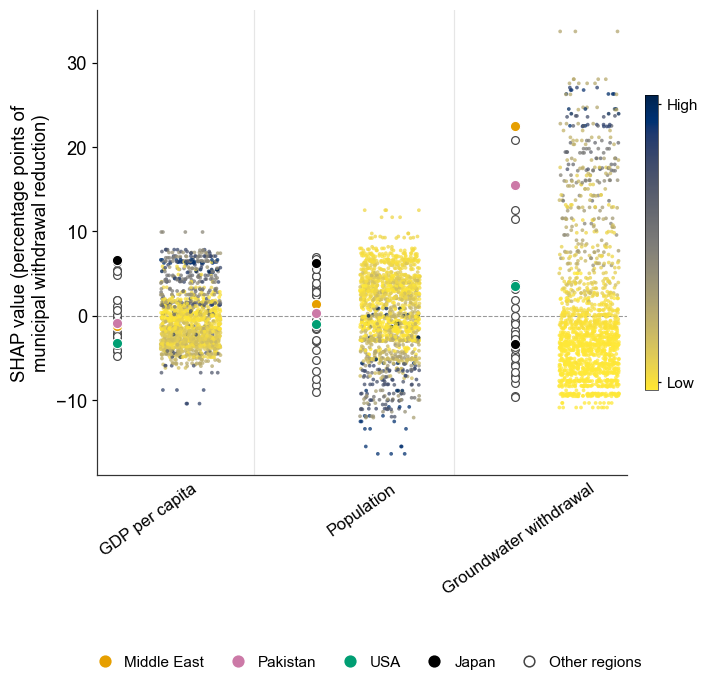

  Saved: figure5_main_shap_MRC_vertical.png


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.collections import LineCollection, PathCollection
from matplotlib.patches import Rectangle

TIER = 'MRC'   # headline tier: adoption is neither suppressed nor saturated

# Colour ramp: light for low attribute values, dark for high ones.
SHAP_VALUE_CMAP = colormaps['cividis_r']

# Exemplar marker and label colours (label takes the marker colour).
STRIP_COLORS.update({
    'Middle East': '#E69F00',   # orange
    'Pakistan':    '#CC79A7',   # reddish purple
    'USA':         '#009E73',   # bluish green
    'Japan':       '#000000',   # black
})

LABEL_OFFSETS = None



def swap_orientation(ax, rotate_labels=35):
    """Turn a horizontal SHAP summary (predictors on y) into a vertical one
    (predictors on x, SHAP on y). Works on whatever draw_shap_main drew."""
    old_xlim, old_ylim = ax.get_xlim(), ax.get_ylim()
    ticks  = ax.get_yticks()
    labels = [t.get_text() for t in ax.get_yticklabels()]
    xlabel = ax.get_xlabel()

    # Points, strips and polygons
    for coll in ax.collections:
        if isinstance(coll, LineCollection):
            coll.set_segments([np.asarray(s)[:, ::-1] for s in coll.get_segments()])
            continue
        off = np.asarray(coll.get_offsets())
        if off.ndim == 2 and len(off) and coll.get_offset_transform() == ax.transData:
            coll.set_offsets(off[:, ::-1])
        elif not isinstance(coll, PathCollection) and coll.get_transform() == ax.transData:
            for p in coll.get_paths():
                p.vertices = p.vertices[:, ::-1]

    # Lines: data lines are swapped, axhline <-> axvline
    for ln in list(ax.lines):
        tr = ln.get_transform()
        style = dict(color=ln.get_color(), lw=ln.get_linewidth(),
                     ls=ln.get_linestyle(), zorder=ln.get_zorder(), alpha=ln.get_alpha())
        if tr == ax.get_yaxis_transform():
            ax.axvline(ln.get_ydata()[0], **style); ln.remove()
        elif tr == ax.get_xaxis_transform():
            ax.axhline(ln.get_xdata()[0], **style); ln.remove()
        else:
            x, y = ln.get_xdata(), ln.get_ydata()
            ln.set_data(y, x)

    # Rectangles in data coordinates (bars, bands)
    for pt in ax.patches:
        if isinstance(pt, Rectangle) and pt.get_transform() == ax.transData:
            x, y, w, h = pt.get_x(), pt.get_y(), pt.get_width(), pt.get_height()
            pt.set_xy((y, x)); pt.set_width(h); pt.set_height(w)

    # Text labels and exemplar annotations
    for t in ax.texts:
        x, y = t.get_position()
        if hasattr(t, 'xy'):                       # annotation
            t.xy = (t.xy[1], t.xy[0])
            if t.anncoords in ('offset points', 'offset pixels'):
                t.set_position((y, x))             # (dx, dy) -> (dy, dx)
            elif t.anncoords == 'data':
                t.set_position((y, x))
        else:
            t.set_position((y, x))

    # Axes: predictors along x, SHAP on y
    ax.set_xlim(sorted(old_ylim))              # first-ranked predictor on the left
    ax.set_ylim(old_xlim)
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels, rotation=rotate_labels, ha='right', rotation_mode='anchor')
    ax.yaxis.set_major_locator(mticker.MaxNLocator(6))
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.set_xlabel(''); ax.set_ylabel(xlabel)
    ax.tick_params(axis='x', length=0)
    ax.tick_params(axis='y', length=3)



# ---------------------------------------------------------------------
# Figure 5 (vertical): predictors along x, SHAP value on y
# ---------------------------------------------------------------------
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(6.6, 6.4))          # narrower -> columns closer
fig.subplots_adjust(left=0.13, right=0.86, top=0.96, bottom=0.30)

order_idx = draw_shap_main(
    ax, shaps[TIER], feat_cols,
    label_offsets=LABEL_OFFSETS,
    strip_rows='all',      # or e.g. ['Groundwater withdrawal']
)

# Drop the mean |SHAP| annotations (reported in the SI tables) and the
# inline exemplar labels (replaced by the legend underneath).
for txt in list(ax.texts):
    t = txt.get_text().strip()
    if t.endswith('pp') or t in STRIP_COLORS:
        txt.remove()

# Lift the opacity of the scenario clouds only; strip markers unchanged.
for coll in ax.collections:
    if len(coll.get_offsets()) > 100:
        coll.set_alpha(0.75)

# Rotate: predictors become columns, the SHAP axis becomes vertical.
swap_orientation(ax, rotate_labels=35)

# Trim the empty margin either side of the outer columns.
lo, hi = ax.get_xlim()
ax.set_xlim(lo + 0.15, hi - 0.15)

ax.set_ylabel('SHAP value (percentage points of\nmunicipal withdrawal reduction)',
              fontsize=12)
ax.tick_params(axis='y', labelsize=12)
for lbl in ax.get_xticklabels():
    lbl.set_fontsize(11)

# Frame: bottom and left spines only.
for side in ('bottom', 'left'):
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(0.8)
    ax.spines[side].set_color('#333333')

# Attribute-value colourbar, vertical on the right, no title.
cax = fig.add_axes([0.885, 0.42, 0.018, 0.42])
sm = plt.cm.ScalarMappable(cmap=SHAP_VALUE_CMAP, norm=plt.Normalize(0, 1))
sm.set_array([])
cb = plt.colorbar(sm, cax=cax, orientation='vertical')
cb.set_ticks([0.03, 0.97]); cb.set_ticklabels(['Low', 'High'])
cb.ax.tick_params(labelsize=10, length=2)
cb.outline.set_linewidth(0.4)

# Exemplar-region legend below the figure, one row.
handles = [Line2D([0], [0], marker='o', linestyle='', markersize=7,
                  markerfacecolor=c, markeredgecolor=c, label=r)
           for r, c in STRIP_COLORS.items() if r in EXEMPLARS]
handles.append(Line2D([0], [0], marker='o', linestyle='', markersize=7,
                      markerfacecolor='white', markeredgecolor='#444444',
                      label='Other regions'))
fig.legend(handles=handles, loc='lower center', ncol=len(handles),
           bbox_to_anchor=(0.5, 0.005), frameon=False, fontsize=10,
           handletextpad=0.3, columnspacing=1.2)


display(fig)
save_fig(fig, FIG_DIR, 'figure5_main_shap_MRC_vertical')


## Supplementary: regression tree and SHAP for each reuse cost tier

One figure per tier, with the per-region SHAP tables for all tiers.

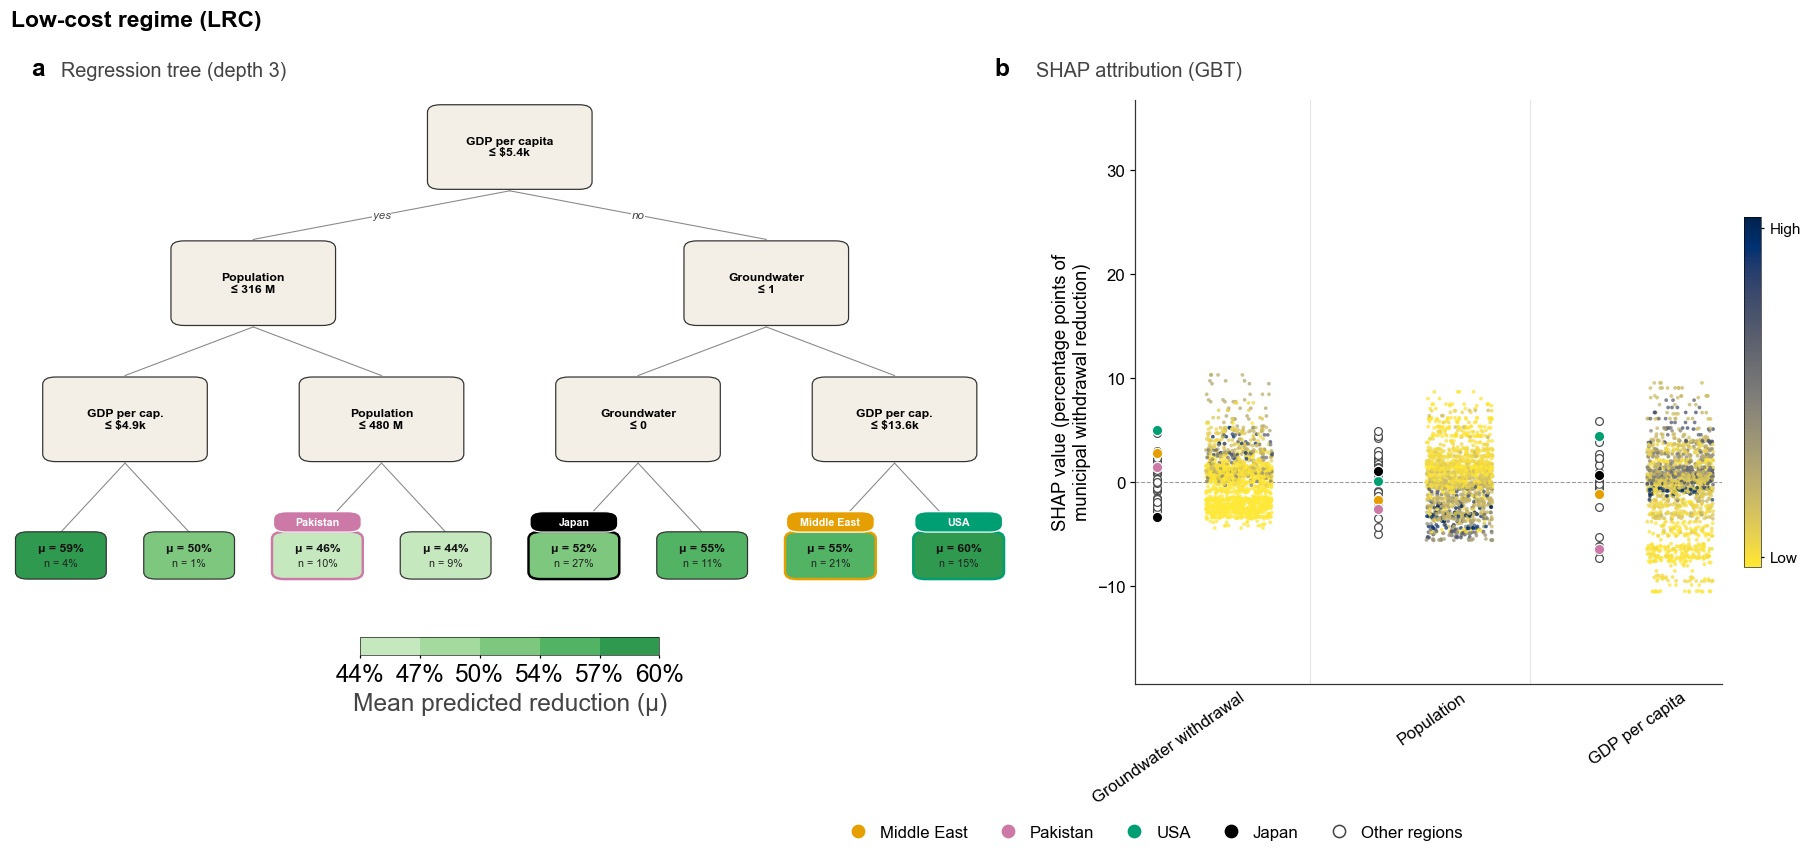

  Saved: SI_fig5_cart_shap_LRC.png


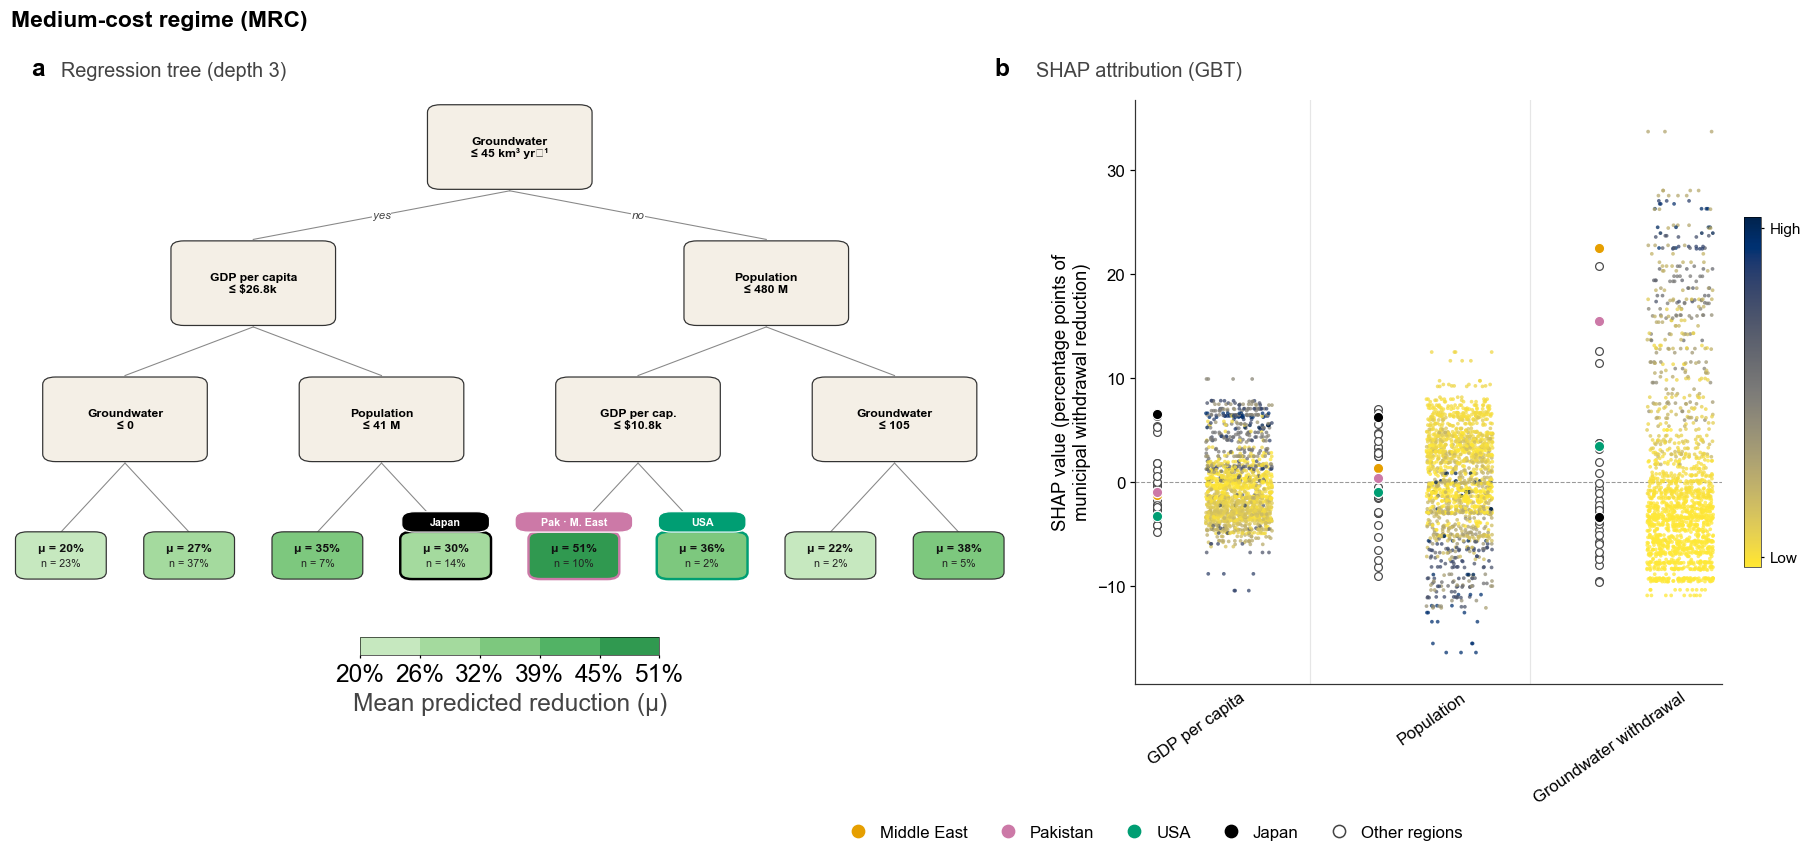

  Saved: SI_fig5_cart_shap_MRC.png


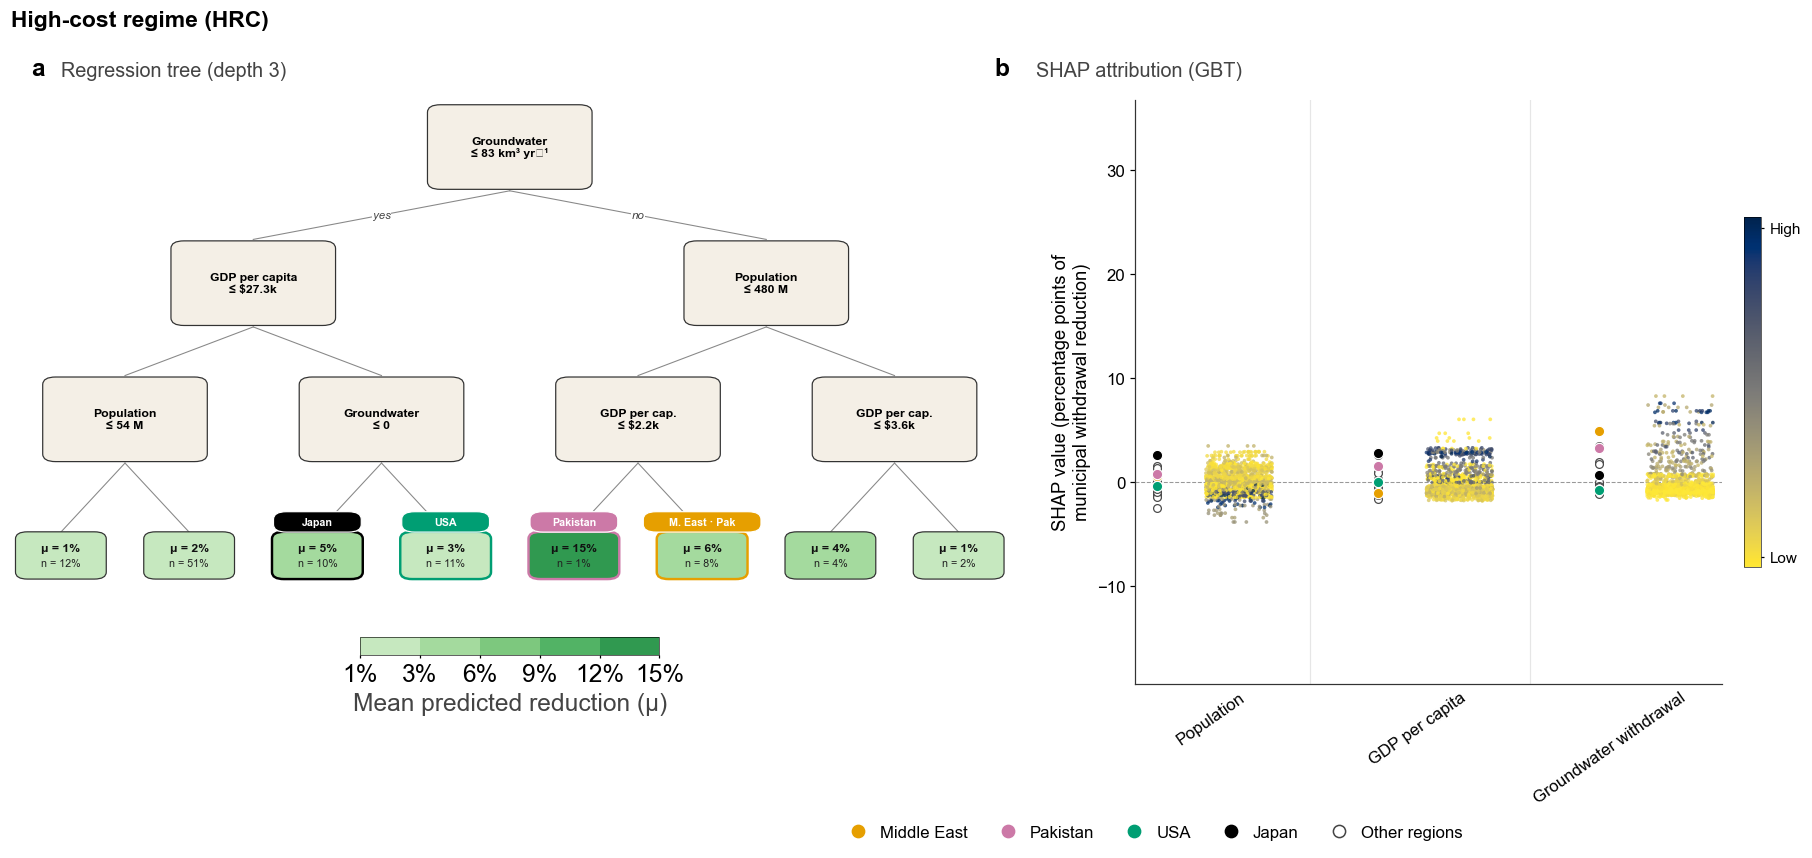

  Saved: SI_fig5_cart_shap_HRC.png
Saved: SI_region_shap_all_tiers.xlsx

=== Model skill and mean |SHAP| by tier ===


,tier,n_rows,n_regions,base_value_pct,cart_oof_r2,rf_oof_r2,gbt_oof_r2,gbt_insample_r2,gbt_oof_mae_pp,mean_abs_shap_GDP per capita,mean_abs_shap_Population,mean_abs_shap_Groundwater withdrawal
0,LRC,1632,32,53.178,-0.112,-0.105,-0.130,0.945,5.692,2.759,2.236,2.071
1,MRC,1632,32,29.432,-0.199,0.180,0.150,0.994,8.178,2.801,3.924,6.585
2,HRC,1632,32,2.696,-0.540,-0.078,-0.197,0.971,2.070,1.039,0.836,1.064



=== Mean SHAP by region and tier (pp), sorted by Groundwater withdrawal at MRC ===


LRC                                                                                           MRC                                                       \
predictor                       Groundwater withdrawal GDP per capita Population Sum of SHAP Model mean (%) Observed mean (%) Groundwater withdrawal GDP per capita Population Sum of SHAP Model mean (%)   
region                                                                                                                                                                                                      
Middle East                                       2.83          -1.15      -1.74       -0.06          53.12             53.06                  22.53          -1.23       1.41       22.71          52.14   
Africa_Northern                                   4.72          -0.50       2.03        6.24          59.42             59.50                  20.82           1.87       3.37       26.06          55.49   
Pakistan                                          1.46          -6.44      -2.59       -7.58          45.60             45.56                  15.51          -0.90       0.36       14.98          44.41   
India                                             2.02          -6.26      -3.45       -7.69          45.49             45.38                  12.59          -1.11      -6.50        4.97          34.41   
Africa_Eastern                                    1.75          -7.27      -5.00      -10.51          42.67             42.45                  11.50           0.65      -8.17        3.99          33.42   
South Asia                                        1.40          -6.62      -2.27       -7.49          45.69             45.26                   3.78          -0.97      -2.86       -0.06          29.38   
Mexico                                            2.37          -0.48       0.43        2.32          55.50             55.62                   3.73          -3.41       2.52        2.84          32.27   
USA                                               4.99           4.49       0.10        9.58          62.75             62.80                   3.53          -3.20      -0.94       -0.60          28.83   
Europe_Non_EU                                     2.98           3.89       1.71        8.58          61.76             61.82                   3.16          -2.19       6.18        7.16          36.59   
Africa_Western                                    0.95          -6.17      -4.27       -9.48          43.69             43.59                   1.92          -0.06      -9.05       -7.20          22.23   
Central Asia                                      1.68           0.35       2.34        4.37          57.54             57.55                   0.87           0.04       5.55        6.46          35.89   
China                                             2.77           5.86      -1.82        6.81          59.99             60.16                  -0.02          -4.14      -7.46      -11.63          17.81   
Africa_Southern                                   0.82          -5.24      -2.44       -6.86          46.32             46.46                  -0.57          -0.36      -2.97       -3.89          25.54   
EU-15                                             1.28           2.68      -0.84        3.12          56.30             56.46                  -1.01           4.82      -0.69        3.12          32.55   
Australia_NZ                                     -0.66           0.02       0.11       -0.52          52.66             52.76                  -1.73           5.41       3.37        7.05          36.48   
South America_Southern                            1.14           0.11       1.33        2.57          55.75             55.19                  -2.21          -2.55       3.94       -0.82          28.61   
Brazil                                           -0.51          -0.26       0.78        0.01          53.19             53.18                  -2.46        


=== Exemplar regions (pp) ===


LRC                                                                                           MRC                                                                         \
predictor   Groundwater withdrawal GDP per capita Population Sum of SHAP Model mean (%) Observed mean (%) Groundwater withdrawal GDP per capita Population Sum of SHAP Model mean (%) Observed mean (%)   
region                                                                                                                                                                                                    
Middle East                   2.83          -1.15      -1.74       -0.06          53.12             53.06                  22.53          -1.23       1.41       22.71          52.14             52.14   
Pakistan                      1.46          -6.44      -2.59       -7.58          45.60             45.56                  15.51          -0.90       0.36       14.98          44.41             44.36   
USA                           4.99           4.49       0.10        9.58          62.75             62.80                   3.53          -3.20      -0.94       -0.60          28.83             28.78   
Japan                        -3.33           0.67       1.09       -1.58          51.60             51.22                  -3.32           6.57       6.30        9.55          38.98             39.06   

                               HRC                                                                         
predictor   Groundwater withdrawal GDP per capita Population Sum of SHAP Model mean (%) Observed mean (%)  
region                                                                                                     
Middle East                   4.92          -1.02       0.64        4.54           7.24              7.24  
Pakistan                      3.25           1.57       0.78        5.60           8.30              8.38  
USA                          -0.78           0.03      -0.34       -1.09           1.61              1.51  
Japan                         0.66           2.86       2.64        6.17           8.86              8.99


=== SI table: mean [q25, q75] (pp) ===


LRC                                                          MRC                                                           HRC                                      
                                Groundwater withdrawal     GDP per capita         Population Groundwater withdrawal     GDP per capita          Population Groundwater withdrawal     GDP per capita         Population
region                                                                                                                                                                                                                 
Middle East                             2.8 [1.8, 3.8]  -1.1 [-1.6, -0.3]  -1.7 [-2.2, -1.1]      22.5 [20.2, 24.5]   -1.2 [-2.1, 0.1]      1.4 [0.5, 2.3]         4.9 [3.0, 6.7]  -1.0 [-1.1, -0.7]     0.6 [0.2, 1.0]
Africa_Northern                         4.7 [3.1, 6.4]   -0.5 [-2.4, 0.8]     2.0 [0.3, 3.6]      20.8 [16.3, 26.2]     1.9 [1.2, 3.4]      3.4 [2.7, 3.9]         3.5 [1.8, 5.4]  -0.9 [-1.3, -0.4]     1.3 [0.9, 1.9]
Pakistan                                1.5 [0.5, 2.4]  -6.4 [-7.6, -4.5]  -2.6 [-3.6, -1.6]      15.5 [14.0, 17.5]   -0.9 [-2.9, 1.2]     0.4 [-1.3, 1.1]         3.3 [1.5, 4.6]    1.6 [-1.0, 4.0]    0.8 [-0.0, 1.0]
India                                   2.0 [0.9, 2.9]  -6.3 [-6.8, -5.2]  -3.5 [-4.2, -3.0]       12.6 [7.5, 16.1]   -1.1 [-2.0, 0.1]  -6.5 [-11.9, -0.9]         1.7 [0.8, 2.2]  -0.8 [-1.1, -0.4]  -1.4 [-1.9, -0.8]
Africa_Eastern                          1.8 [0.9, 2.8]  -7.3 [-7.9, -6.1]  -5.0 [-5.5, -4.8]       11.5 [6.2, 17.9]     0.7 [0.2, 1.0]  -8.2 [-10.2, -5.9]         1.9 [0.9, 2.7]     0.9 [0.6, 1.5]  -2.5 [-3.0, -1.7]
South Asia                              1.4 [0.3, 2.1]  -6.6 [-7.3, -6.7]  -2.3 [-3.0, -1.5]        3.8 [-0.7, 8.2]   -1.0 [-2.4, 0.2]   -2.9 [-6.2, -0.0]      -0.4 [-0.7, -0.2]  -0.8 [-1.0, -0.5]  -0.2 [-0.3, -0.0]
Mexico                                  2.4 [0.9, 3.6]   -0.5 [-0.7, 0.2]    0.4 [-0.4, 1.5]         3.7 [0.7, 6.8]  -3.4 [-4.2, -2.5]      2.5 [1.9, 3.0]        0.1 [-0.3, 0.6]  -0.5 [-0.5, -0.5]     0.8 [0.7, 1.0]
USA                                     5.0 [2.3, 6.9]     4.5 [3.8, 6.1]    0.1 [-0.2, 1.0]        3.5 [-0.8, 8.5]   -3.2 [-5.9, 0.6]    -0.9 [-2.8, 1.2]      -0.8 [-1.5, -0.0]    0.0 [-1.1, 0.6]  -0.3 [-0.5, -0.3]
Europe_Non_EU                           3.0 [1.1, 4.4]     3.9 [0.3, 5.1]     1.7 [0.3, 1.3]        3.2 [-2.0, 8.1]  -2.2 [-2.9, -1.4]      6.2 [3.7, 7.9]       -0.2 [-0.6, 0.3]  -0.4 [-0.5, -0.4]     0.7 [0.5, 0.8]
Africa_Western                          1.0 [0.7, 1.1]  -6.2 [-7.3, -4.9]  -4.3 [-4.9, -3.5]         1.9 [0.1, 3.3]   -0.1 [-0.5, 0.4]  -9.1 [-10.5, -7.5]      -0.3 [-0.5, -0.2]    0.1 [-0.1, 0.3]  -1.0 [-1.3, -0.9]
Central Asia                           1.7 [-0.1, 4.1]    0.3 [-0.9, 1.9]     2.3 [0.9, 3.6]        0.9 [-5.4, 5.6]    0.0 [-1.4, 1.7]      5.6 [3.3, 8.2]      -0.5 [-1.0, -0.4]  -0.9 [-0.9, -0.8]     0.4 [0.2, 0.4]
China                                   2.8 [1.5, 3.6]     5.9 [4.0, 7.5]  -1.8 [-2.2, -1.1]       -0.0 [-2.3, 1.7]  -4.1 [-4.5, -3.4]   -7.5 [-8.1, -6.4]      -0.4 [-0.6, -0.2]  -1.0 [-1.0, -0.9]  -1.1 [-1.3, -0.9]
Africa_Southern                         0.8 [0.3, 1.2]  -5.2 [-6.6, -3.0]  -2.4 [-3.0, -2.0]      -0.6 [-1.3, -0.1]  -0.4 [-0.6, -0.0]   -3.0 [-3.0, -2.6]      -1.0 [-1.2, -0.7]     0.3 [0.1, 0.6]     0.2 [0.1, 0.3]
EU-15                                   1.3 [0.3, 2.4]     2.7 [2.0, 3.4]  -0.8 [-0.7, -0.4]       -1.0 [-2.5, 0.3]     4.8 [4.3, 6.5]   -0.7 [-0.9, -0.1]      -1.0 [-1.1, -0.9]     1.5 [1.4, 1.6]     0.2 [0.1, 0.2]
Australia_NZ                          -0.7 [-2.3, 0.6]    0.0 [-0.7, 0.7]    0.1 [-0.5, 0.6]       -1.7 [-3.3, 0.1]     5.4 [4.2, 7.4]      3.4 [2.7, 4.2]      -0.2 [-0.5, -0.1]     2.6 [2.2, 3.2]     1.2 [0.4, 1.8]
South America_Southern                  1.1 [0.7, 1.4]    0.1 [-1.2, 0.3]     1.3 [1.4, 2.6]      -2.2 [-3.3, -1.1]  -2.5 [-3.2, -2.2]      3.9 [3.4, 4.6]      -0.


Figures: C:\Users\Sarfr001\Documents\Global_Potential_Potable_Reuse\outputs\figure5\SI
Tables : C:\Users\Sarfr001\Documents\Global_Potential_Potable_Reuse\outputs\figure5\tables


In [13]:
# =====================================================================
# SUPPLEMENTARY: regression tree and SHAP for every reuse cost tier, and
# the per-region SHAP table across tiers. Uses swap_orientation from the
# Figure 5 cell above.
#
# Outputs
#   SI/SI_fig5_cart_shap_<tier>.png                      one per tier
#   tables/SI_region_shap_all_tiers_long.csv             tidy, all numbers
#   tables/SI_region_shap_all_tiers_wide.csv             regions x (tier, predictor)
#   tables/SI_region_shap_all_tiers_formatted.csv        "mean [q25, q75]" strings
#   tables/SI_model_skill_by_tier.csv                    R2 and base value per tier
#   tables/SI_region_shap_all_tiers.xlsx                 all of the above as sheets
#   tables/cart_leaf_regions_<tier>.csv                  leaf rosters
# =====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
import shap
from IPython.display import display

assert 'swap_orientation' in globals(), 'Run the Figure 5 cell first.'

# ---------------------------------------------------------------------
# 0. Settings (reset here because an earlier cell overwrites them)
# ---------------------------------------------------------------------
SI_EXEMPLARS = ['Middle East', 'Pakistan', 'USA', 'Japan']
SI_COLORS = {'Middle East': '#E69F00', 'Pakistan': '#CC79A7',
             'USA': '#009E73', 'Japan': '#000000'}

EXEMPLARS = list(SI_EXEMPLARS)
STRIP_COLORS.clear(); STRIP_COLORS.update(SI_COLORS)
EXEMPLAR_COLORS.update(SI_COLORS)        # CART chips match the SHAP markers
SHAP_VALUE_CMAP = colormaps['cividis_r']

TIER_TITLES = globals().get('TIER_TITLES', {
    'LRC': 'Low-cost regime', 'MRC': 'Medium-cost regime',
    'HRC': 'High-cost regime'})

TIERS = [t for t in RC_ORDER if t in shaps]
pretty_cols = [pretty_name(c) for c in feat_cols]

# Shared SHAP axis across tiers so magnitudes are comparable by eye.
_all = np.concatenate([shaps[t]['shap_values'].ravel() for t in TIERS])
_pad = 0.06 * (_all.max() - _all.min())
SI_YLIM = (_all.min() - _pad, _all.max() + _pad)


# ---------------------------------------------------------------------
# 1. SHAP panel drawn onto an existing axis (same idiom as Figure 5)
# ---------------------------------------------------------------------
def draw_shap_vertical_on(ax, tier, ylim=SI_YLIM):
    draw_shap_main(ax, shaps[tier], feat_cols, exemplars=SI_EXEMPLARS,
                   label_offsets=None, strip_rows='all')
    for txt in list(ax.texts):                       # drop pp notes and inline labels
        s = txt.get_text().strip()
        if s.endswith('pp') or s in SI_COLORS:
            txt.remove()
    for coll in ax.collections:                      # lift scenario clouds only
        if len(coll.get_offsets()) > 100:
            coll.set_alpha(0.75)
    swap_orientation(ax, rotate_labels=35)
    lo, hi = ax.get_xlim()
    ax.set_xlim(lo + 0.15, hi - 0.15)
    ax.set_ylim(ylim)
    ax.set_ylabel('SHAP value (percentage points of\n'
                  'municipal withdrawal reduction)', fontsize=12)
    ax.tick_params(axis='y', labelsize=11)
    for lbl in ax.get_xticklabels():
        lbl.set_fontsize(11)
    for side in ('bottom', 'left'):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(0.8)
        ax.spines[side].set_color('#333333')


# ---------------------------------------------------------------------
# 2. One SI figure per tier: (a) regression tree, (b) SHAP
# ---------------------------------------------------------------------
for tier in TIERS:
    fit_t = fits[tier]
    m = fit_t['metrics']

    chips_t, leaf_t = leaf_region_assignments(
        fit_t, matrix, feat_cols, exemplars=SI_EXEMPLARS, tier=tier)
    leaf_t.to_csv(TAB_DIR / f'cart_leaf_regions_{tier}.csv', index=False)

    fig = plt.figure(figsize=(17, 7.8))
    gs = GridSpec(1, 2, width_ratios=[1.7, 1.0], wspace=0.16,
                  left=0.01, right=0.925, top=0.88, bottom=0.20)
    ax_a = fig.add_subplot(gs[0, 0])
    ax_b = fig.add_subplot(gs[0, 1])

    # (a) CART
    draw_custom_cart(ax_a, fit_t, feat_cols, chips_t,
                     show_panel_label=False, show_colorbar=True)
    ax_a.text(0.02, 1.035, 'a', transform=ax_a.transAxes, fontsize=16,
              fontweight='bold', ha='left', va='bottom')
    ax_a.text(0.05, 1.035,
              f'Regression tree (depth 3)',
              transform=ax_a.transAxes, fontsize=13, color='#444',
              ha='left', va='bottom')

    # (b) SHAP
    draw_shap_vertical_on(ax_b, tier)
    ax_b.text(-0.24, 1.035, 'b', transform=ax_b.transAxes, fontsize=16,
              fontweight='bold', ha='left', va='bottom')
    ax_b.text(-0.17, 1.035,
              f'SHAP attribution (GBT) ',
              transform=ax_b.transAxes, fontsize=13, color='#444',
              ha='left', va='bottom')

    # Attribute-value colorbar to the right of panel b.
    pos = ax_b.get_position()
    cax = fig.add_axes([pos.x1 + 0.012, pos.y0 + 0.2 * pos.height,
                        0.009, 0.6 * pos.height])
    sm = plt.cm.ScalarMappable(cmap=SHAP_VALUE_CMAP, norm=plt.Normalize(0, 1))
    sm.set_array([])
    cb = plt.colorbar(sm, cax=cax, orientation='vertical')
    cb.set_ticks([0.03, 0.97]); cb.set_ticklabels(['Low', 'High'])
    cb.ax.tick_params(labelsize=10, length=2); cb.outline.set_linewidth(0.4)

    # Tier title and shared region legend.
    fig.suptitle(f'{TIER_TITLES.get(tier, tier)} ({tier})', x=0.01, y=0.985,
                 ha='left', fontsize=15, fontweight='bold')
    handles = [Line2D([0], [0], marker='o', linestyle='', markersize=8,
                      markerfacecolor=SI_COLORS[r], markeredgecolor=SI_COLORS[r],
                      label=r) for r in SI_EXEMPLARS]
    handles.append(Line2D([0], [0], marker='o', linestyle='', markersize=8,
                          markerfacecolor='white', markeredgecolor='#444444',
                          label='Other regions'))
    fig.legend(handles=handles, loc='lower center', ncol=len(handles),
               bbox_to_anchor=(0.62, 0.0), frameon=False, fontsize=11,
               handletextpad=0.3, columnspacing=1.4)

    display(fig)
    save_fig(fig, SI_DIR, f'SI_fig5_cart_shap_{tier}')


# ---------------------------------------------------------------------
# 3. Per-region SHAP table for every tier
# ---------------------------------------------------------------------
long_rows, skill_rows = [], []
for tier in TIERS:
    fit_t, pkg = fits[tier], shaps[tier]
    base = float(np.ravel(shap.TreeExplainer(fit_t['gbt']).expected_value)[0])

    t = region_spread_shap(pkg, feat_cols).rename(
        columns={'mean': 'mean_pp', 'q25': 'q25_pp', 'q75': 'q75_pp'})
    t['iqr_pp'] = t['q75_pp'] - t['q25_pp']
    t.insert(0, 'tier', tier)
    long_rows.append(t)

    m = fit_t['metrics']
    skill_rows.append({
        'tier': tier, 'n_rows': m['n_total'], 'n_regions': m['n_regions'],
        'base_value_pct': base,
        'cart_oof_r2': m['cart']['oof_r2'], 'rf_oof_r2': m['rf']['oof_r2'],
        'gbt_oof_r2': m['gbt']['oof_r2'], 'gbt_insample_r2': m['gbt']['insample_r2'],
        'gbt_oof_mae_pp': m['gbt']['oof_mae'],
        **{f'mean_abs_shap_{p}': v for p, v in
           shap_per_feature(pkg, feat_cols).set_index('pretty')['mean_abs'].items()},
    })

long_df  = pd.concat(long_rows, ignore_index=True)
skill_df = pd.DataFrame(skill_rows)
long_df.to_csv(TAB_DIR / 'SI_region_shap_all_tiers_long.csv', index=False)
skill_df.to_csv(TAB_DIR / 'SI_model_skill_by_tier.csv', index=False)

# Wide numeric: regions x (tier, predictor), plus the regional sum and the
# model and observed mean reduction, so readers can check base + sum = model.
wide_parts = []
for tier in TIERS:
    w = (long_df[long_df['tier'] == tier]
         .pivot(index='region', columns='predictor', values='mean_pp')[pretty_cols])
    w['Sum of SHAP'] = w.sum(axis=1)
    base = skill_df.set_index('tier').loc[tier, 'base_value_pct']
    w['Model mean (%)'] = base + w['Sum of SHAP']
    obs = fits[tier]['y_train'].groupby(fits[tier]['r_train'].values).mean()
    w['Observed mean (%)'] = obs.reindex(w.index)
    w.columns = pd.MultiIndex.from_product([[tier], w.columns])
    wide_parts.append(w)
wide_df = pd.concat(wide_parts, axis=1)

lead_tier = 'MRC' if 'MRC' in TIERS else TIERS[0]
lead_pred = shap_per_feature(shaps[lead_tier], feat_cols)['pretty'].iloc[0]
wide_df = wide_df.sort_values((lead_tier, lead_pred), ascending=False)
wide_df.round(2).to_csv(TAB_DIR / 'SI_region_shap_all_tiers_wide.csv')

# Formatted SI table: "mean [q25, q75]" per tier and predictor.
long_df['cell'] = long_df.apply(
    lambda r: f'{r.mean_pp:.1f} [{r.q25_pp:.1f}, {r.q75_pp:.1f}]', axis=1)
fmt_df = (long_df.pivot_table(index='region', columns=['tier', 'predictor'],
                              values='cell', aggfunc='first')
          .reindex(columns=pd.MultiIndex.from_product([TIERS, pretty_cols]))
          .loc[wide_df.index])
fmt_df.to_csv(TAB_DIR / 'SI_region_shap_all_tiers_formatted.csv')

ex_df = wide_df.loc[[r for r in SI_EXEMPLARS if r in wide_df.index]]

try:
    with pd.ExcelWriter(TAB_DIR / 'SI_region_shap_all_tiers.xlsx') as xw:
        fmt_df.to_excel(xw, sheet_name='SI table (mean, IQR)')
        wide_df.round(2).to_excel(xw, sheet_name='All tiers numeric')
        ex_df.round(2).to_excel(xw, sheet_name='Exemplar regions')
        skill_df.round(3).to_excel(xw, sheet_name='Model skill', index=False)
        long_df.drop(columns='cell').round(3).to_excel(
            xw, sheet_name='Long form', index=False)
    print('Saved: SI_region_shap_all_tiers.xlsx')
except Exception as e:
    print(f'Excel export skipped ({e}); CSV files are written.')

# ---------------------------------------------------------------------
# 4. Print
# ---------------------------------------------------------------------
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 40)
print('\n=== Model skill and mean |SHAP| by tier ===')
display(skill_df.round(3))
print(f'\n=== Mean SHAP by region and tier (pp), sorted by {lead_pred} at {lead_tier} ===')
display(wide_df.round(2))
print('\n=== Exemplar regions (pp) ===')
display(ex_df.round(2))
print('\n=== SI table: mean [q25, q75] (pp) ===')
display(fmt_df)
print('\nFigures:', SI_DIR.resolve()); print('Tables :', TAB_DIR.resolve())